# CAC × LTV — Onde Aumentar ou Reduzir Investimento por Plataforma e Marca

Este notebook conecta **custo de mídia (CAC)** com **valor do paciente no tempo (LTV)** para responder:
> **Onde aumentar ou reduzir o investimento?**

**Fontes de dados**
- `prj-analytics-ga.testes.vw_meta_google_ads` — investimento, impressões e cliques diários por conta
- `prj-analytics-ga.testes.tb_temporal_class_pac_atd2` — receita e classificação de pacientes por mês
- `prj-analytics-ga.testes.tb_de_para_conta_marca` — mapeamento conta ads → marca

**Cobertura:** 2024 em diante

**Outputs gerados**
- Tabela completa CAC × LTV com marcos 3, 6, 12 e 24 meses
- Matriz Retenção × LTV por plataforma e marca
- Ranking de canais por eficiência (Ratio LTV:CAC)
- Diagnóstico de payback period e semáforo de saúde


## 1. Configuração

Parâmetros de filtragem e diretório de saída.

> **Ajuste `DATA_INICIO`** se quiser ampliar a janela de análise.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import pandas as pd
from google.cloud import bigquery
from google.cloud import bigquery_storage

# ── Parâmetros globais ──────────────────────────────────────────────────────
DATA_INICIO    = "2024-01-01"   # início da cobertura de mídia
MES_REFERENCIA = 12            # marco LTV para decisão de investimento (meses)

PLATAFORMAS    = ["google_ads", "meta_ads"]
CHANNEL_MAP    = {"google_ads": "Paid Search", "meta_ads": "Paid Social"}

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 2. Query BigQuery — CAC × LTV

A query é dividida em 5 CTEs encadeadas:

1. **`custo_midia`** — agrega custo mensal por plataforma + marca (via tabela de-para). Contas sem marca são excluídas.
2. **`pacientes_novos`** — conta pacientes novos digitais por mês / plataforma / marca e calcula o ticket de aquisição.
3. **`cac_base`** — cruzamento custo × pacientes; calcula CAC, CPC e taxa de conversão.
4. **`ltv_marcos`** — LTV acumulado médio por coorte nos marcos 3, 6, 12 e 24 meses.
5. **Output final** — junta tudo e deriva Ratio LTV:CAC, Breakeven, Payback Period e Semáforo.

**Melhorias em relação à versão anterior**
- Coorte de aquisição usa `QUALIFY ROW_NUMBER()` para garantir exatamente **um** mês-coorte por paciente (evita duplicatas quando o mesmo CPF aparece em dois canais no mesmo mês).
- `tamanho_coorte` calculado **antes** do join com marca, eliminando over-counting.
- LTV acumulado calculado com `SUM() OVER (... ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)` particionado apenas por `(mes_coorte, canal_aquisicao, marca_aquisicao)` — sem `grupo_exames` para não inflar o denominador.
- Semáforo baseado em `ratio_ltv_cac_12m` com três faixas: Saudável ≥ 3 | Atenção ≥ 2 | Crítico < 2.


In [2]:
query = """
-- ============================================================
-- CAC + LTV + Breakeven por Plataforma e Marca
-- ============================================================
WITH

  -- PASSO 1: Custo mensal por plataforma + marca
  -- Usa join direto via tabela de-para; exclui contas sem marca.
  custo_midia AS (
    SELECT
      DATE_TRUNC(ads.data, MONTH)   AS mes_midia,
      ads.plataforma,
      ads.nome_da_conta,
      dp.marca                      AS marca_ads,
      dp.status                     AS status_depara,
      SUM(ads.investimento)         AS custo_total_mes,
      SUM(ads.impressoes)           AS impressoes_mes,
      SUM(ads.cliques)              AS cliques_mes
    FROM `prj-analytics-ga.testes.vw_meta_google_ads` ads
    INNER JOIN `prj-analytics-ga.testes.tb_de_para_conta_marca` dp
      ON dp.nome_da_conta = ads.nome_da_conta
    WHERE
      ads.data  >= '{DATA_INICIO}'
      AND dp.marca IS NOT NULL       -- exclui SEM MARCA
      AND dp.status <> 'INATIVO'    -- exclui contas desativadas
    GROUP BY ALL
  ),

  -- PASSO 2: Pacientes NOVOS digitais — coorte precisa (sem duplicatas por CPF)
  -- QUALIFY garante um único mês-coorte por paciente.
  coorte_aquisicao AS (
    SELECT
      nu_cpf_paciente,
      mes_atendimento                                         AS mes_coorte,
      COALESCE(NULLIF(channel_group, 'Nao Identificado'),
               origem_agd, 'Nao Identificado')               AS channel_group,
      marca
    FROM `prj-analytics-ga.testes.tb_temporal_class_pac_atd2`
    WHERE
      classificacao_paciente_dasa = 'novo'
      AND channel_group IN ('Paid Search', 'Paid Social')
      AND mes_atendimento >= '{DATA_INICIO}'
    QUALIFY ROW_NUMBER() OVER (
      PARTITION BY nu_cpf_paciente
      ORDER BY mes_atendimento ASC
    ) = 1
  ),

  -- Tamanho real da coorte por (mes_coorte, canal, marca)
  tamanho_coorte AS (
    SELECT
      mes_coorte,
      channel_group,
      marca,
      COUNT(DISTINCT nu_cpf_paciente) AS tamanho_coorte
    FROM coorte_aquisicao
    GROUP BY ALL
  ),

  -- Receita mensal por paciente (todos os atendimentos, não apenas novos)
  receita_por_mes AS (
    SELECT
      nu_cpf_paciente,
      mes_atendimento,
      SUM(receita) AS receita_mes
    FROM `prj-analytics-ga.testes.tb_temporal_class_pac_atd2`
    GROUP BY nu_cpf_paciente, mes_atendimento
  ),

  -- PASSO 3: Pacientes novos + receita do mês de aquisição + plataforma
  pacientes_novos AS (
    SELECT
      tc.mes_coorte                                             AS mes_aquisicao,
      tc.marca,
      tc.channel_group,
      CASE
        WHEN tc.channel_group = 'Paid Search' THEN 'google_ads'
        WHEN tc.channel_group = 'Paid Social' THEN 'meta_ads'
        ELSE 'outros_digital'
      END                                                       AS plataforma,
      tc.tamanho_coorte                                         AS pacientes_novos,
      ROUND(SUM(r.receita_mes), 2)                             AS receita_mes_aquisicao,
      ROUND(SUM(r.receita_mes)
            / NULLIF(tc.tamanho_coorte, 0), 2)                AS ticket_medio_aquisicao
    FROM tamanho_coorte tc
    LEFT JOIN (
      SELECT ca.nu_cpf_paciente, ca.mes_coorte, r.receita_mes
      FROM coorte_aquisicao ca
      INNER JOIN receita_por_mes r
        ON r.nu_cpf_paciente = ca.nu_cpf_paciente
        AND r.mes_atendimento = ca.mes_coorte
    ) r ON r.mes_coorte = tc.mes_coorte
    GROUP BY tc.mes_coorte, tc.marca, tc.channel_group, tc.tamanho_coorte
  ),

  -- PASSO 4: CAC = custo / pacientes novos (join por mês + plataforma + marca)
  cac_base AS (
    SELECT
      pn.mes_aquisicao,
      pn.plataforma,
      pn.marca,
      pn.channel_group,
      pn.pacientes_novos,
      pn.receita_mes_aquisicao,
      pn.ticket_medio_aquisicao,
      cm.nome_da_conta,
      cm.status_depara,
      COALESCE(cm.custo_total_mes, 0)  AS custo_midia_mes,
      COALESCE(cm.impressoes_mes, 0)   AS impressoes_mes,
      COALESCE(cm.cliques_mes, 0)      AS cliques_mes,
      ROUND(COALESCE(cm.custo_total_mes, 0)
            / NULLIF(pn.pacientes_novos, 0), 2)  AS cac,
      ROUND(COALESCE(cm.custo_total_mes, 0)
            / NULLIF(cm.cliques_mes, 0), 2)      AS cpc,
      ROUND(100.0 * pn.pacientes_novos
            / NULLIF(cm.cliques_mes, 0), 4)      AS taxa_conversao_clique_pct
    FROM pacientes_novos pn
    LEFT JOIN custo_midia cm
      ON  cm.mes_midia = pn.mes_aquisicao
      AND cm.plataforma = pn.plataforma
      AND cm.marca_ads  = pn.marca
  ),

  -- PASSO 5: LTV acumulado nos marcos 3, 6, 12 e 24 meses
  -- Denominador fixo no tamanho original da coorte (pacientes adquiridos no mês 0)
  coorte_receita AS (
    SELECT
      ca.mes_coorte,
      ca.channel_group,
      ca.marca,
      r.mes_atendimento,
      DATE_DIFF(r.mes_atendimento, ca.mes_coorte, MONTH) AS mes_desde_aquisicao,
      r.receita_mes
    FROM coorte_aquisicao ca
    INNER JOIN receita_por_mes r
      ON  r.nu_cpf_paciente  = ca.nu_cpf_paciente
      AND r.mes_atendimento  >= ca.mes_coorte
      AND DATE_DIFF(r.mes_atendimento, ca.mes_coorte, MONTH) <= 24
  ),

  ltv_agg AS (
    SELECT
      mes_coorte,
      channel_group,
      marca,
      mes_desde_aquisicao,
      COUNT(DISTINCT cr.mes_atendimento)  AS coortes_ativas,
      SUM(receita_mes)                    AS receita_total_mes
    FROM coorte_receita cr
    GROUP BY ALL
  ),

  ltv_acumulado AS (
    SELECT
      la.*,
      tc.tamanho_coorte,
      ROUND(
        SUM(la.receita_total_mes) OVER (
          PARTITION BY la.mes_coorte, la.channel_group, la.marca
          ORDER BY la.mes_desde_aquisicao
          ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) / NULLIF(tc.tamanho_coorte, 0), 2
      ) AS ltv_medio_por_paciente
    FROM ltv_agg la
    LEFT JOIN tamanho_coorte tc
      ON  tc.mes_coorte    = la.mes_coorte
      AND tc.channel_group = la.channel_group
      AND tc.marca         = la.marca
  ),

  ltv_marcos AS (
    SELECT
      mes_coorte,
      channel_group                                                          AS canal_aquisicao,
      marca                                                                  AS marca_aquisicao,
      MAX(CASE WHEN mes_desde_aquisicao =  3 THEN ltv_medio_por_paciente END) AS ltv_3m,
      MAX(CASE WHEN mes_desde_aquisicao =  6 THEN ltv_medio_por_paciente END) AS ltv_6m,
      MAX(CASE WHEN mes_desde_aquisicao = 12 THEN ltv_medio_por_paciente END) AS ltv_12m,
      MAX(CASE WHEN mes_desde_aquisicao = 24 THEN ltv_medio_por_paciente END) AS ltv_24m,
      MAX(tamanho_coorte)                                                    AS tamanho_coorte
    FROM ltv_acumulado
    GROUP BY mes_coorte, channel_group, marca
  )

-- ============================================================
-- OUTPUT FINAL
-- ============================================================
SELECT
  cb.mes_aquisicao,
  cb.plataforma,
  cb.nome_da_conta,
  cb.status_depara,
  cb.marca,
  cb.channel_group,

  -- Volume
  cb.pacientes_novos,
  cb.impressoes_mes,
  cb.cliques_mes,

  -- Eficiência de mídia
  cb.cpc,
  cb.taxa_conversao_clique_pct,

  -- Custo e CAC
  cb.custo_midia_mes,
  cb.cac,

  -- Receita no mês de aquisição
  cb.receita_mes_aquisicao,
  cb.ticket_medio_aquisicao,

  -- LTV por marco
  lm.ltv_3m,
  lm.ltv_6m,
  lm.ltv_12m,
  lm.ltv_24m,

  -- Relação LTV:CAC
  ROUND(lm.ltv_3m  / NULLIF(cb.cac, 0), 2) AS ratio_ltv_cac_3m,
  ROUND(lm.ltv_6m  / NULLIF(cb.cac, 0), 2) AS ratio_ltv_cac_6m,
  ROUND(lm.ltv_12m / NULLIF(cb.cac, 0), 2) AS ratio_ltv_cac_12m,
  ROUND(lm.ltv_24m / NULLIF(cb.cac, 0), 2) AS ratio_ltv_cac_24m,

  -- Breakeven (quantos atendimentos para cobrir o CAC)
  ROUND(cb.cac / NULLIF(cb.ticket_medio_aquisicao, 0), 1) AS breakeven_atendimentos,

  -- Payback period
  CASE
    WHEN lm.ltv_3m  >= cb.cac THEN '≤ 3 meses'
    WHEN lm.ltv_6m  >= cb.cac THEN '4–6 meses'
    WHEN lm.ltv_12m >= cb.cac THEN '7–12 meses'
    WHEN lm.ltv_24m >= cb.cac THEN '13–24 meses'
    ELSE '> 24 meses ou sem dados'
  END AS payback_period,

  -- Semáforo LTV:CAC 12m
  CASE
    WHEN ROUND(lm.ltv_12m / NULLIF(cb.cac, 0), 2) >= 3 THEN 'Saudável'
    WHEN ROUND(lm.ltv_12m / NULLIF(cb.cac, 0), 2) >= 2 THEN 'Atenção'
    WHEN ROUND(lm.ltv_12m / NULLIF(cb.cac, 0), 2) >  0 THEN 'Crítico'
    ELSE 'Sem dados LTV'
  END AS status_canal_ltv_cac

FROM cac_base cb
LEFT JOIN ltv_marcos lm
  ON  lm.mes_coorte      = cb.mes_aquisicao
  AND lm.canal_aquisicao = cb.channel_group
  AND lm.marca_aquisicao = cb.marca
ORDER BY
  cb.mes_aquisicao DESC,
  cb.plataforma,
  cb.marca
""".format(DATA_INICIO=DATA_INICIO)


## 3. Carregar Dados

Executa a query no BigQuery. Se der erro aqui, verifique permissão, autenticação ou nomes de colunas.

In [3]:
client           = bigquery.Client()
bqstorage_client = bigquery_storage.BigQueryReadClient()

df = client.query(query).result().to_dataframe(bqstorage_client=bqstorage_client)

# Tipos
df["mes_aquisicao"] = pd.to_datetime(df["mes_aquisicao"])

# Colunas numéricas: garantia de float
cols_num = [
    "cac", "cpc", "taxa_conversao_clique_pct",
    "ltv_3m", "ltv_6m", "ltv_12m", "ltv_24m",
    "ratio_ltv_cac_3m", "ratio_ltv_cac_6m", "ratio_ltv_cac_12m", "ratio_ltv_cac_24m",
    "breakeven_atendimentos", "ticket_medio_aquisicao",
    "receita_mes_aquisicao", "custo_midia_mes",
]
for c in cols_num:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Linhas carregadas  : {len(df):,}")
print(f"Período            : {df['mes_aquisicao'].min().date()} → {df['mes_aquisicao'].max().date()}")
print(f"Plataformas        : {df['plataforma'].unique().tolist()}")
print(f"Marcas distintas   : {df['marca'].nunique()}")
print(f"Contas com REVISAR : {(df['status_depara'] == 'REVISAR').sum()}")
df.head()


Linhas carregadas  : 780
Período            : 2024-01-01 → 2026-05-01
Plataformas        : ['google_ads', 'meta_ads']
Marcas distintas   : 32
Contas com REVISAR : 0


,mes_aquisicao,plataforma,nome_da_conta,status_depara,marca,channel_group,pacientes_novos,impressoes_mes,cliques_mes,cpc,...,ltv_6m,ltv_12m,ltv_24m,ratio_ltv_cac_3m,ratio_ltv_cac_6m,ratio_ltv_cac_12m,ratio_ltv_cac_24m,breakeven_atendimentos,payback_period,status_canal_ltv_cac
0,2026-05-01,google_ads,Alta,MAPEADO,ALTA,Paid Search,178,5069411.00000000000000000000000000000000000000,225909.00000000000000000000000000000000000000,1.72,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1,> 24 meses ou sem dados,Sem dados LTV
1,2026-05-01,google_ads,None,None,ATALAIA,Paid Search,1,0E-38,0E-38,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,> 24 meses ou sem dados,Sem dados LTV
2,2026-05-01,google_ads,Boris Berenstein,MAPEADO,BORIS BERENSTEIN,Paid Search,53,238883.00000000000000000000000000000000000000,28318.00000000000000000000000000000000000000,0.49,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,> 24 meses ou sem dados,Sem dados LTV
3,2026-05-01,google_ads,Bronstein,MAPEADO,BRONSTEIN,Paid Search,364,2016191.00000000000000000000000000000000000000,218758.00000000000000000000000000000000000000,0.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,> 24 meses ou sem dados,Sem dados LTV
4,2026-05-01,google_ads,CDPI,MAPEADO,CDPI,Paid Search,92,2483811.00000000000000000000000000000000000000,97550.00000000000000000000000000000000000000,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,> 24 meses ou sem dados,Sem dados LTV


## 4. Funções Utilitárias

Formatação em reais e helpers de agregação reutilizados nas seções seguintes.

In [9]:


NUM_COLS = [
    "pacientes_novos",
    "custo_midia_mes",
    "receita_mes_aquisicao",
    "cliques_mes",
    "impressoes_mes",
    "ltv_3m", "ltv_6m", "ltv_12m", "ltv_24m",
]

df[NUM_COLS] = df[NUM_COLS].apply(pd.to_numeric, errors="coerce")




def agg_por_plataforma_marca(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega o dataframe linha-a-linha (um mês por linha) em nível
    (plataforma, marca), calculando médias ponderadas por pacientes_novos.
    Usado nos rankings e na matriz.
    """
    g = (
        df_raw
        .groupby(["plataforma", "marca"], as_index=False)
        .agg(
            pacientes_novos        =("pacientes_novos",        "sum"),
            custo_total            =("custo_midia_mes",        "sum"),
            receita_total_aquisicao=("receita_mes_aquisicao",  "sum"),
            cliques_total          =("cliques_mes",            "sum"),
            impressoes_total       =("impressoes_mes",         "sum"),
            # Mediana dos marcos LTV (robusta a outliers mensais)
            ltv_3m  =("ltv_3m",   "median"),
            ltv_6m  =("ltv_6m",   "median"),
            ltv_12m =("ltv_12m",  "median"),
            ltv_24m =("ltv_24m",  "median"),
            # Pega o status_canal mais recente
            status  =("status_canal_ltv_cac", "last"),
        )
    )
    g["cac"]              = g["custo_total"]             / g["pacientes_novos"].replace(0, np.nan)
    g["ticket_medio"]     = g["receita_total_aquisicao"] / g["pacientes_novos"].replace(0, np.nan)
    g["cpc"]              = g["custo_total"]             / g["cliques_total"].replace(0, np.nan)
    g["taxa_conv_pct"]    = g["pacientes_novos"]         / g["cliques_total"].replace(0, np.nan)
    g["ratio_ltv_cac_12m"]= g["ltv_12m"]                / g["cac"].replace(0, np.nan)
    g["ratio_ltv_cac_24m"]= g["ltv_24m"]                / g["cac"].replace(0, np.nan)
    g["breakeven"]        = g["cac"]                     / g["ticket_medio"].replace(0, np.nan)
    return g.sort_values("ratio_ltv_cac_12m", ascending=False)


## 5. Resumo Executivo por Plataforma

Visão consolidada Google Ads vs. Meta Ads — o ponto de partida da decisão de orçamento.

In [6]:
resumo_plataforma = (
    df
    .groupby("plataforma", as_index=False)
    .agg(
        pacientes_novos        =("pacientes_novos",        "sum"),
        custo_total            =("custo_midia_mes",        "sum"),
        receita_total_aquisicao=("receita_mes_aquisicao",  "sum"),
        ltv_12m_median         =("ltv_12m",  "median"),
        ltv_24m_median         =("ltv_24m",  "median"),
    )
)
resumo_plataforma["cac"]               = resumo_plataforma["custo_total"] / resumo_plataforma["pacientes_novos"].replace(0, np.nan)
resumo_plataforma["ratio_ltv_cac_12m"] = resumo_plataforma["ltv_12m_median"] / resumo_plataforma["cac"].replace(0, np.nan)
resumo_plataforma["ratio_ltv_cac_24m"] = resumo_plataforma["ltv_24m_median"] / resumo_plataforma["cac"].replace(0, np.nan)

fmt_resumo = pd.DataFrame({
    "Plataforma"        : resumo_plataforma["plataforma"],
    "Pacientes Novos"   : resumo_plataforma["pacientes_novos"].map(lambda v: f"{v:,.0f}"),
    "Custo Total"       : resumo_plataforma["custo_total"].map(fmt_brl),
    "CAC Médio"         : resumo_plataforma["cac"].map(fmt_brl),
    "LTV Mediano 12m"   : resumo_plataforma["ltv_12m_median"].map(fmt_brl),
    "LTV Mediano 24m"   : resumo_plataforma["ltv_24m_median"].map(fmt_brl),
    "Ratio LTV:CAC 12m" : resumo_plataforma["ratio_ltv_cac_12m"].map(lambda v: f"{v:.2f}x" if pd.notna(v) else "—"),
    "Ratio LTV:CAC 24m" : resumo_plataforma["ratio_ltv_cac_24m"].map(lambda v: f"{v:.2f}x" if pd.notna(v) else "—"),
})
fmt_resumo.set_index("Plataforma", inplace=True)
display(fmt_resumo)


,Pacientes Novos,Custo Total,CAC Médio,LTV Mediano 12m,LTV Mediano 24m,Ratio LTV:CAC 12m,Ratio LTV:CAC 24m
Plataforma,,,,,,,
google_ads,"109,252",R$ 39.653.688,R$ 363,R$ 14.724,R$ 19.865,40.57x,54.73x
meta_ads,340,R$ 2.116.351,R$ 6.225,R$ 14.328,R$ 9.614,2.30x,1.54x


## 6. Ranking de Marcas — Eficiência LTV:CAC

Cada linha é uma marca × plataforma. O **Ratio LTV:CAC 12m** é o critério primário de ordenação.

| Faixa     | Semáforo  | Interpretação                                      |
|-----------|-----------|---------------------------------------------------|
| ≥ 3x      | 🟢 Saudável | Cada R$ de CAC gera ≥ R$ 3 de LTV em 12 meses   |
| 2x – 3x   | 🟡 Atenção  | Retorno positivo, mas abaixo do benchmark ideal  |
| < 2x      | 🔴 Crítico  | CAC não se paga em 12 meses — rever ou cortar    |


In [10]:
ranking = agg_por_plataforma_marca(df)

def semaforo(status: str) -> str:
    return {"Saudável": "🟢", "Atenção": "🟡", "Crítico": "🔴"}.get(status, "⚪")


fmt_ranking = pd.DataFrame({
    "Plataforma"         : ranking["plataforma"],
    "Marca"              : ranking["marca"],
    "Pacientes Novos"    : ranking["pacientes_novos"].map(lambda v: f"{v:,.0f}"),
    "Custo Total"        : ranking["custo_total"].map(fmt_brl),
    "CAC"                : ranking["cac"].map(fmt_brl),
    "LTV 12m"            : ranking["ltv_12m"].map(fmt_brl),
    "LTV 24m"            : ranking["ltv_24m"].map(fmt_brl),
    "Ratio LTV:CAC 12m"  : ranking["ratio_ltv_cac_12m"].map(lambda v: f"{v:.2f}x" if pd.notna(v) else "—"),
    "Ratio LTV:CAC 24m"  : ranking["ratio_ltv_cac_24m"].map(lambda v: f"{v:.2f}x" if pd.notna(v) else "—"),
    "Breakeven (atend.)" : ranking["breakeven"].map(lambda v: f"{v:.1f}x" if pd.notna(v) else "—"),
    "Semáforo"           : ranking["status"].map(semaforo),
})
fmt_ranking.set_index(["Plataforma", "Marca"], inplace=True)
display(fmt_ranking)



Pacientes Novos   Custo Total        CAC  \
Plataforma Marca                                                               
google_ads ALVARO                                36      R$ 1.320      R$ 37   
           IMAGE MEMORIAL                     2,380    R$ 266.860     R$ 112   
           LAVOISIER                         42,150  R$ 6.997.045     R$ 166   
           LAMINA                               961    R$ 218.560     R$ 227   
           SALOMAO E ZOPPI                    5,836  R$ 1.795.931     R$ 308   
           DELBONI                           25,940  R$ 9.353.518     R$ 361   
           BRONSTEIN                          9,867  R$ 3.000.987     R$ 304   
           CERPE                              1,828    R$ 386.965     R$ 212   
           FRISCHMANN AISENGART               2,820    R$ 893.966     R$ 317   
           EXAME                              4,024  R$ 2.324.614     R$ 578   
           BORIS BERENSTEIN                     476    R$ 101.577     R$ 213   
           LEME                                 640    R$ 377.747     R$ 590   
           ALTA                               4,458  R$ 9.415.516   R$ 2.112   
meta_ads   EXAME                                 35    R$ 105.877   R$ 3.025   
google_ads SERGIO FRANCO                      3,602  R$ 2.900.067     R$ 805   
           CDPI                               1,114  R$ 1.485.742   R$ 1.334   
meta_ads   FRISCHMANN AISENGART                  10     R$ 38.270   R$ 3.827   
           DELBONI                               13    R$ 281.385  R$ 21.645   
           LAVOISIER                            186    R$ 916.943   R$ 4.930   
           SERGIO FRANCO                         25    R$ 243.163   R$ 9.727   
google_ads ATALAIA                               24          R$ 0       R$ 0   
           CEDIC CEDILAB                         32          R$ 0       R$ 0   
           CYTOLAB                              986          R$ 0       R$ 0   
           DELIBERATO                           784          R$ 0       R$ 0   
           GHANEM                                 4      R$ 1.017     R$ 254   
           ITULAB                                92          R$ 0       R$ 0   
           LABORATORIO OSWALDO CRUZ              77          R$ 0       R$ 0   
           LAMINA SC                             32          R$ 0       R$ 0   
           LUSTOSA                                4          R$ 0       R$ 0   
           MEDIMAGEM                            216          R$ 0       R$ 0   
           MULTIIMAGEM                           33          R$ 0       R$ 0   
           PREVILAB                             370          R$ 0       R$ 0   
           SANTA LUZIA                          164     R$ 17.121     R$ 104   
           SAO CAMILO                           122     R$ 73.074     R$ 599   
           SAO MARCOS                           107     R$ 42.060     R$ 393   
           VALECLIN                              63          R$ 0       R$ 0   
           VITAL BRASIL                          10          R$ 0       R$ 0   
meta_ads   ALTA                                   7    R$ 218.139  R$ 31.163   
           BRONSTEIN                             48    R$ 245.825   R$ 5.121   
           CDPI                                   1        R$ 727     R$ 727   
           CERPE                                  5     R$ 17.125   R$ 3.425   
           CYTOLAB                                2          R$ 0       R$ 0   
           IMAGE MEMORIAL                         1      R$ 1.004   R$ 1.004   
           LAMINA                                 1        R$ 972     R$ 972   
           SALOMAO E ZOPPI                        6     R$ 46.921   R$ 7.820   

                                       LTV 12m    LTV 24m Ratio LTV:CAC 12m  \
Plataforma Marca                                                              
google_ads ALVARO                    R$ 11.752   R$ 2.920           320.48x   
           IMAGE MEMORIAL            R

## 7. Gráfico — Ratio LTV:CAC 12m por Marca × Plataforma

Barras coloridas pelo semáforo. A linha tracejada em **2x** é o threshold mínimo aceitável; em **3x** é o benchmark saudável.

C:\Users\F39860419825\AppData\Local\Temp\ipykernel_4180\3233818312.py:31: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\F39860419825\AppData\Local\Temp\ipykernel_4180\3233818312.py:31: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\F39860419825\AppData\Local\Temp\ipykernel_4180\3233818312.py:31: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\F39860419825\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\F39860419825\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figur

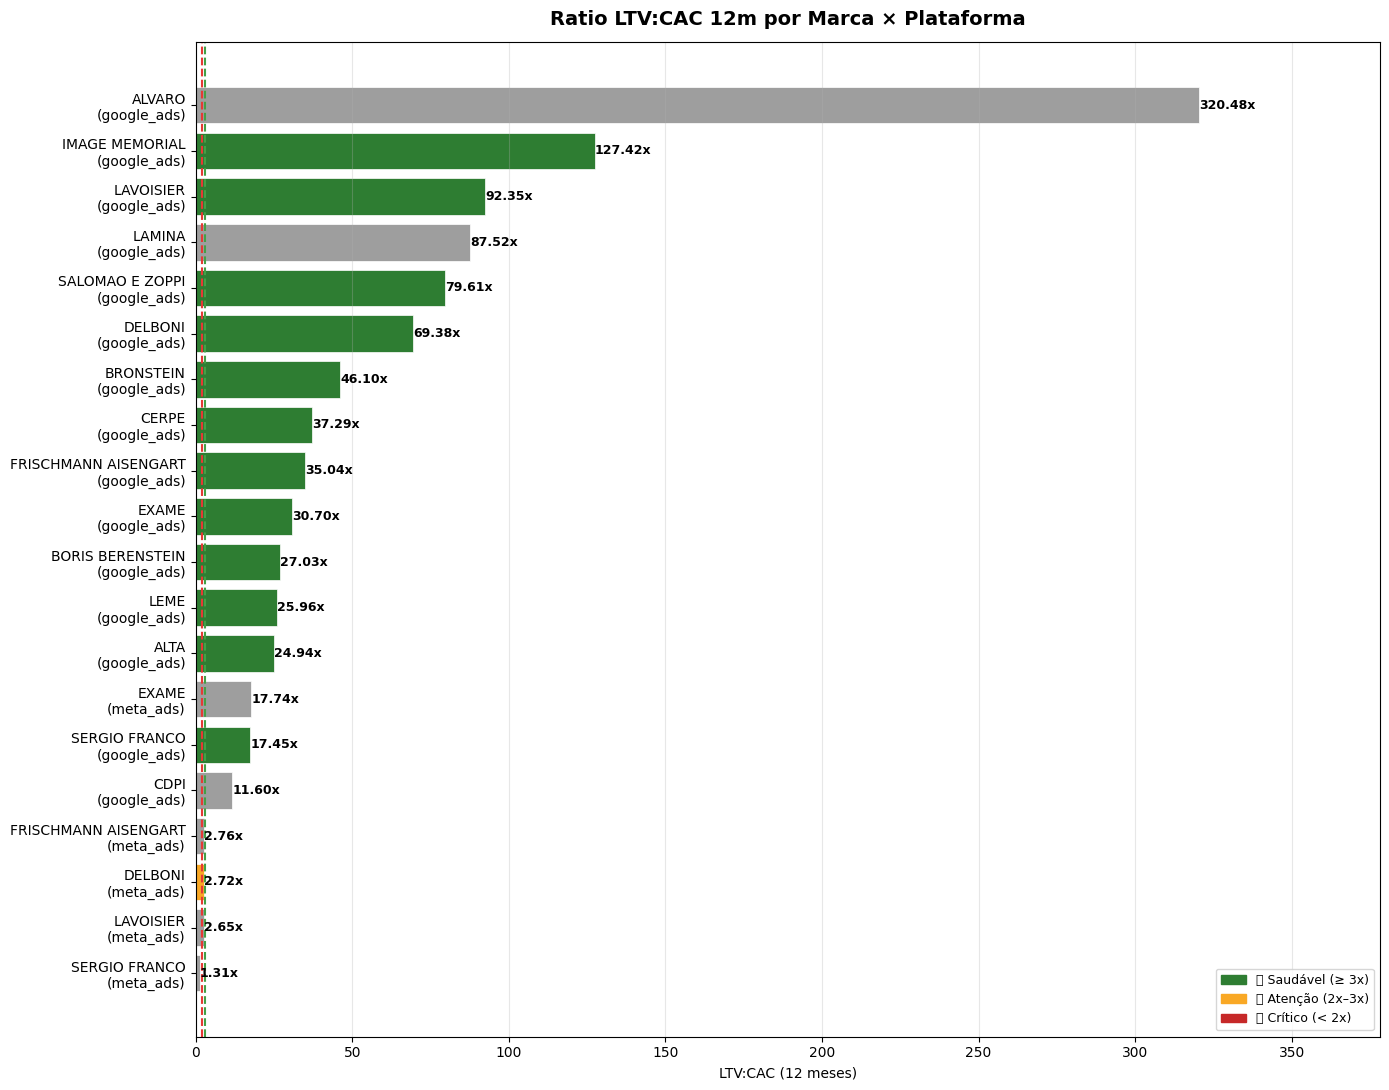

In [12]:
dados_bar = ranking.dropna(subset=["ratio_ltv_cac_12m"]).sort_values("ratio_ltv_cac_12m", ascending=True)
labels    = dados_bar["marca"] + "\n(" + dados_bar["plataforma"] + ")"

COLOR_MAP = {"Saudável": "#2E7D32", "Atenção": "#F9A825", "Crítico": "#C62828", "Sem dados LTV": "#9E9E9E"}
cores     = dados_bar["status"].map(COLOR_MAP).fillna("#9E9E9E")

fig, ax = plt.subplots(figsize=(14, max(6, len(dados_bar) * 0.55)))
bars = ax.barh(labels, dados_bar["ratio_ltv_cac_12m"], color=cores, edgecolor="white", linewidth=0.5)

# Anotações de valor
for bar, val in zip(bars, dados_bar["ratio_ltv_cac_12m"]):
    ax.text(
        bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}x", va="center", ha="left", fontsize=9, fontweight="bold"
    )

ax.axvline(2, color="#E53935", linestyle="--", linewidth=1.5, label="Mínimo aceitável (2x)")
ax.axvline(3, color="#43A047", linestyle="--", linewidth=1.5, label="Benchmark saudável (3x)")

legend_patches = [
    mpatches.Patch(color=COLOR_MAP["Saudável"], label="🟢 Saudável (≥ 3x)"),
    mpatches.Patch(color=COLOR_MAP["Atenção"],  label="🟡 Atenção (2x–3x)"),
    mpatches.Patch(color=COLOR_MAP["Crítico"],  label="🔴 Crítico (< 2x)"),
]
ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0][2:], loc="lower right", fontsize=9)

ax.set_title("Ratio LTV:CAC 12m por Marca × Plataforma", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("LTV:CAC (12 meses)")
ax.set_xlim(left=0, right=dados_bar["ratio_ltv_cac_12m"].max() * 1.18)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "ratio_ltv_cac_marcas.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Matriz Retenção × LTV por Marca × Plataforma

Posiciona cada segmento em dois eixos:
- **Eixo X** — taxa de retenção no mês 12 (pacientes ainda ativos ÷ tamanho da coorte)
- **Eixo Y** — LTV acumulado médio até o mês 12

O **tamanho do ponto** é proporcional ao volume de pacientes captados.

### Interpretação dos quadrantes

| Quadrante                    | Ação recomendada                                                    |
|------------------------------|---------------------------------------------------------------------|
| ⬆ Alta retenção + Alto LTV  | **Aumentar investimento** — canal ideal                             |
| ★ Baixa retenção + Alto LTV | **Investigar:** LTV alto mas não fideliza — oportunidade de CRM    |
| ⬆ Alta retenção + Baixo LTV | **Manter com cautela** — fidelizados, mas ticket baixo             |
| ⬇ Baixa retenção + Baixo LTV| **Reduzir ou pausar investimento** — pior combinação               |


In [14]:

def criar_matriz_retencao_ltv_cac(df_base: pd.DataFrame, mes_ref: int = 12) -> pd.DataFrame:
    """
    Calcula LTV acumulado e taxa de retenção no mes_ref para cada (plataforma, marca).
    Filtra apenas coortes que já completaram mes_ref (coortes elegíveis).
    """
    from google.cloud import bigquery as _bq

    query_retencao = f"""
    WITH
      coorte AS (
        SELECT
          nu_cpf_paciente,
          mes_atendimento  AS mes_coorte,
          COALESCE(NULLIF(channel_group, 'Nao Identificado'),
                   origem_agd, 'Nao Identificado') AS channel_group,
          marca,
          CASE
            WHEN channel_group = 'Paid Search' THEN 'google_ads'
            WHEN channel_group = 'Paid Social' THEN 'meta_ads'
            ELSE 'outros_digital'
          END AS plataforma
        FROM `prj-analytics-ga.testes.tb_temporal_class_pac_atd2`
        WHERE classificacao_paciente_dasa = 'novo'
          AND channel_group IN ('Paid Search', 'Paid Social')
          AND mes_atendimento >= '{DATA_INICIO}'
        QUALIFY ROW_NUMBER() OVER (
          PARTITION BY nu_cpf_paciente ORDER BY mes_atendimento ASC
        ) = 1
      ),

      tamanho AS (
        SELECT plataforma, marca, mes_coorte,
               COUNT(DISTINCT nu_cpf_paciente) AS tamanho_coorte
        FROM coorte
        GROUP BY plataforma, marca, mes_coorte
      ),

      receita AS (
        SELECT nu_cpf_paciente, mes_atendimento, SUM(receita) AS receita_mes
        FROM `prj-analytics-ga.testes.tb_temporal_class_pac_atd2`
        GROUP BY nu_cpf_paciente, mes_atendimento
      ),

      juncao AS (
        SELECT
          c.plataforma, c.marca, c.mes_coorte,
          c.nu_cpf_paciente,
          r.mes_atendimento,
          DATE_DIFF(r.mes_atendimento, c.mes_coorte, MONTH) AS mes_desde_aquisicao,
          r.receita_mes
        FROM coorte c
        INNER JOIN receita r
          ON r.nu_cpf_paciente = c.nu_cpf_paciente
         AND r.mes_atendimento >= c.mes_coorte
         AND DATE_DIFF(r.mes_atendimento, c.mes_coorte, MONTH) <= {mes_ref}
      ),

      mensal AS (
        SELECT
          plataforma, marca, mes_coorte, mes_desde_aquisicao,
          MAX(mes_atendimento) AS mes_atendimento,
          COUNT(DISTINCT nu_cpf_paciente) AS pacientes_ativos,
          SUM(receita_mes) AS receita_mes
        FROM juncao
        GROUP BY plataforma, marca, mes_coorte, mes_desde_aquisicao
      )

    SELECT
      m.plataforma, m.marca, m.mes_coorte, m.mes_desde_aquisicao,
      m.mes_atendimento,
      m.pacientes_ativos,
      t.tamanho_coorte,
      m.receita_mes,
      SUM(m.receita_mes) OVER (
        PARTITION BY m.plataforma, m.marca, m.mes_coorte
        ORDER BY m.mes_desde_aquisicao
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
      ) AS receita_acumulada
    FROM mensal m
    LEFT JOIN tamanho t
      ON t.plataforma = m.plataforma
     AND t.marca = m.marca
     AND t.mes_coorte = m.mes_coorte
    ORDER BY m.plataforma, m.marca, m.mes_coorte, m.mes_desde_aquisicao
    """

    df_ret = (
        _bq.Client()
        .query(query_retencao)
        .result()
        .to_dataframe(bqstorage_client=bqstorage_client)
    )

    # Tipos
    df_ret["mes_coorte"] = pd.to_datetime(df_ret["mes_coorte"])
    df_ret["mes_atendimento"] = pd.to_datetime(df_ret["mes_atendimento"])

    # Data fim real do dataset retornado
    data_fim = df_ret["mes_atendimento"].max()

    resultados = []

    for (plat, marca), g in df_ret.groupby(["plataforma", "marca"], dropna=False):
        coortes_info = g[["mes_coorte", "tamanho_coorte"]].drop_duplicates().copy()

        # idade_meses (vectorizado e correto)
        coortes_info["idade_meses"] = (
            (data_fim.year - coortes_info["mes_coorte"].dt.year) * 12
            + (data_fim.month - coortes_info["mes_coorte"].dt.month)
        )

        elegiveis = coortes_info[coortes_info["idade_meses"] >= mes_ref]
        volume_total = coortes_info["tamanho_coorte"].sum()

        if elegiveis.empty:
            resultados.append({
                "plataforma": plat,
                "marca": marca,
                "ltv_final": np.nan,
                "retencao": np.nan,
                "volume_pacientes": volume_total,
                "coortes_elegiveis": 0,
                "mes_referencia": mes_ref
            })
            continue

        g_eleg = g[g["mes_coorte"].isin(elegiveis["mes_coorte"])]
        g_mes = g_eleg[g_eleg["mes_desde_aquisicao"] == mes_ref]
        tam_el = elegiveis["tamanho_coorte"].sum()

        if g_mes.empty or tam_el <= 0:
            ltv = np.nan
            retencao = np.nan
        else:
            # LTV acumulado médio ponderado por tamanho das coortes elegíveis
            ltv = g_mes["receita_acumulada"].sum() / tam_el
            # Retenção ponderada
            retencao = g_mes["pacientes_ativos"].sum() / tam_el

        resultados.append({
            "plataforma": plat,
            "marca": marca,
            "ltv_final": ltv,
            "retencao": retencao,
            "volume_pacientes": volume_total,
            "coortes_elegiveis": int(len(elegiveis)),
            "mes_referencia": mes_ref
        })

    return pd.DataFrame(resultados)


# Uso
df_matriz = criar_matriz_retencao_ltv_cac(df, mes_ref=MES_REFERENCIA)
display(df_matriz)

ServiceUnavailable: 503 WSAGetOverlappedResult: Connection reset (An existing connection was forcibly closed by the remote host.
 -- 10054)

## 9. Plot da Matriz Retenção × LTV

In [ ]:
def plotar_matriz_cac(df_m: pd.DataFrame, titulo: str, caminho_saida: Path = None) -> None:
    dados = df_m.dropna(subset=["ltv_final", "retencao"]).copy()
    if dados.empty:
        print("Sem dados suficientes para plotar a matriz.")
        display(df_m)
        return

    mediana_ltv = dados["ltv_final"].median()
    mediana_ret = dados["retencao"].median()

    fig, ax = plt.subplots(figsize=(15, 8))
    tamanhos = (dados["volume_pacientes"] / dados["volume_pacientes"].max()) * 2000 + 100

    CORES_PLAT = {"google_ads": "#4285F4", "meta_ads": "#1877F2"}
    cores = dados["plataforma"].map(CORES_PLAT).fillna("#78909C")

    ax.scatter(dados["retencao"], dados["ltv_final"],
               s=tamanhos, c=cores, alpha=0.65, edgecolors="white", linewidth=1.5)

    for _, row in dados.iterrows():
        ax.annotate(
            f"{row['marca']}
({row['plataforma']})",
            xy=(row["retencao"], row["ltv_final"]),
            xytext=(10, 4), textcoords="offset points",
            fontsize=8, fontweight="bold",
        )

    ax.axvline(mediana_ret, linestyle="--", linewidth=1.5, color="#1565C0", alpha=0.7)
    ax.axhline(mediana_ltv, linestyle="--", linewidth=1.5, color="#1565C0", alpha=0.7)

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    pad_x = (x_max - x_min) * 0.02
    pad_y = (y_max - y_min) * 0.02

    quadrantes = [
        (pad_x,              pad_y,              "⬇ Rever aquisição\nRetenção baixa + LTV baixo",   "#C62828"),
        (mediana_ret+pad_x,  pad_y,              "⬆ Fidelizados pouco rentáveis\nRetenção alta + LTV baixo", "#F57F17"),
        (pad_x,              mediana_ltv+pad_y,  "★ Nicho premium\nRetenção baixa + LTV alto",     "#1565C0"),
        (mediana_ret+pad_x,  mediana_ltv+pad_y,  "✦ Aumentar investimento\nRetenção alta + LTV alto", "#2E7D32"),
    ]
    for xq, yq, label, cor in quadrantes:
        ax.text(xq, yq, label, fontsize=9, alpha=0.7, fontstyle="italic", color=cor)

    legend_patches = [
        mpatches.Patch(color="#4285F4", label="Google Ads"),
        mpatches.Patch(color="#1877F2", label="Meta Ads"),
    ]
    ax.legend(handles=legend_patches, loc="upper left", fontsize=10)

    mes_ref = int(dados["mes_referencia"].iloc[0])
    ax.set_title(f"{titulo} | Mês {mes_ref}", fontsize=14, fontweight="bold", pad=14)
    ax.set_xlabel(f"Taxa de Retenção no mês {mes_ref}", fontsize=12)
    ax.set_ylabel("LTV Acumulado Médio por Paciente", fontsize=12)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt_brl(x)))
    ax.grid(alpha=0.25)
    plt.tight_layout()

    if caminho_saida:
        plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
        print(f"Imagem salva: {caminho_saida}")

    plt.show()


plotar_matriz_cac(
    df_matriz,
    titulo="Matriz Retenção × LTV por Marca × Plataforma",
    caminho_saida=OUTPUT_DIR / f"matriz_retencao_ltv_mes{MES_REFERENCIA}.png",
)


## 10. Tendência Mensal do CAC por Plataforma

Evolução do CAC mês a mês — identifica sazonalidade e mudanças de eficiência ao longo do tempo.

In [ ]:
tendencia = (
    df
    .groupby(["mes_aquisicao", "plataforma"], as_index=False)
    .agg(
        custo_total    =("custo_midia_mes",  "sum"),
        pacientes_novos=("pacientes_novos",  "sum"),
    )
)
tendencia["cac"] = tendencia["custo_total"] / tendencia["pacientes_novos"].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(14, 5))
for plat, g in tendencia.groupby("plataforma"):
    g_sorted = g.sort_values("mes_aquisicao")
    ax.plot(g_sorted["mes_aquisicao"], g_sorted["cac"],
            marker="o", linewidth=2.5, label=plat)
    ultimo = g_sorted.iloc[-1]
    ax.annotate(
        fmt_brl(ultimo["cac"]),
        xy=(ultimo["mes_aquisicao"], ultimo["cac"]),
        xytext=(6, 4), textcoords="offset points", fontsize=9, fontweight="bold",
    )

ax.set_title("CAC Mensal por Plataforma", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Mês de Aquisição")
ax.set_ylabel("CAC (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt_brl(x)))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tendencia_cac_mensal.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Diagnóstico de Payback Period

Distribuição dos registros mês × marca por faixa de payback — mostra qual proporção do investimento se paga em cada janela temporal.

In [ ]:
payback_dist = (
    df
    .dropna(subset=["payback_period"])
    .groupby(["plataforma", "payback_period"])
    .agg(
        registros      =("mes_aquisicao",   "count"),
        custo_total    =("custo_midia_mes",  "sum"),
        pacientes_novos=("pacientes_novos",  "sum"),
    )
    .reset_index()
)

ORDEM_PAYBACK = ["≤ 3 meses", "4–6 meses", "7–12 meses", "13–24 meses", "> 24 meses ou sem dados"]
payback_dist["payback_period"] = pd.Categorical(payback_dist["payback_period"],
                                                 categories=ORDEM_PAYBACK, ordered=True)
payback_dist = payback_dist.sort_values(["plataforma", "payback_period"])

display(
    payback_dist
    .assign(custo_total=lambda x: x["custo_total"].map(fmt_brl))
    .rename(columns={
        "plataforma"    : "Plataforma",
        "payback_period": "Payback Period",
        "registros"     : "Meses-Marca",
        "custo_total"   : "Custo Total",
        "pacientes_novos": "Pacientes Novos",
    })
)


## 12. Recomendação de Investimento — Síntese

Geração automática de recomendações com base no Ratio LTV:CAC 12m consolidado por (plataforma, marca).

| Condição                        | Recomendação                      |
|---------------------------------|-----------------------------------|
| Ratio ≥ 3x                      | **Aumentar** — rentabilidade alta |
| 2x ≤ Ratio < 3x                 | **Manter** — monitorar tendência  |
| Ratio < 2x                      | **Reduzir / Pausar** — rever      |
| Sem dados LTV (marca muito nova) | **Aguardar** — coletar mais dados |


In [ ]:
rec = agg_por_plataforma_marca(df)[
    ["plataforma", "marca", "pacientes_novos", "custo_total",
     "cac", "ltv_12m", "ltv_24m", "ratio_ltv_cac_12m", "status"]
].copy()

def recomendar(row):
    ratio = row["ratio_ltv_cac_12m"]
    if pd.isna(ratio):
        return "⚪ Aguardar — sem dados LTV suficientes"
    if ratio >= 3:
        return "🟢 AUMENTAR investimento"
    if ratio >= 2:
        return "🟡 MANTER — monitorar tendência"
    return "🔴 REDUZIR / PAUSAR — rever estratégia"

rec["recomendacao"] = rec.apply(recomendar, axis=1)

fmt_rec = pd.DataFrame({
    "Plataforma"          : rec["plataforma"],
    "Marca"               : rec["marca"],
    "Pacientes Novos"     : rec["pacientes_novos"].map(lambda v: f"{v:,.0f}"),
    "Custo Total"         : rec["custo_total"].map(fmt_brl),
    "CAC"                 : rec["cac"].map(fmt_brl),
    "LTV 12m"             : rec["ltv_12m"].map(fmt_brl),
    "Ratio LTV:CAC 12m"   : rec["ratio_ltv_cac_12m"].map(lambda v: f"{v:.2f}x" if pd.notna(v) else "—"),
    "Recomendação"        : rec["recomendacao"],
})
fmt_rec.set_index(["Plataforma", "Marca"], inplace=True)

print("=" * 70)
print("  RECOMENDAÇÕES DE INVESTIMENTO — LTV × CAC")
print("=" * 70)
display(fmt_rec)

rec.to_csv(OUTPUT_DIR / "recomendacoes_investimento.csv", index=False)
print(f"\nCSV salvo: {OUTPUT_DIR / 'recomendacoes_investimento.csv'}")
